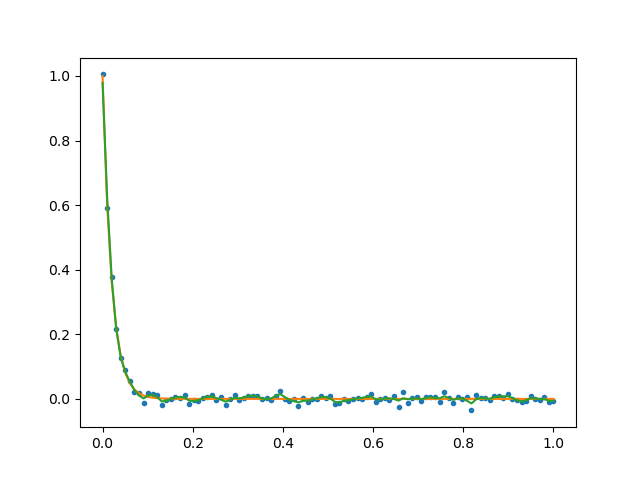

In [1]:
from scipy.interpolate import make_smoothing_spline
import numpy as np
from matplotlib import pyplot as plt

%matplotlib widget

np.random.seed(1234)
n = 100
x = np.linspace(0,10,100)
def func(x):
   return np.exp(-5*x)#x**3 + x**2 * np.sin(4 * x)

y = func(x) + np.random.normal(scale=0.01, size=n)

spl = make_smoothing_spline(x,y)

fig,ax = plt.subplots()
ax.plot(x/x[-1],y, '.')
ax.plot(x/x[-1], func(x))
ax.plot(x/x[-1], spl(x))
plt.show()

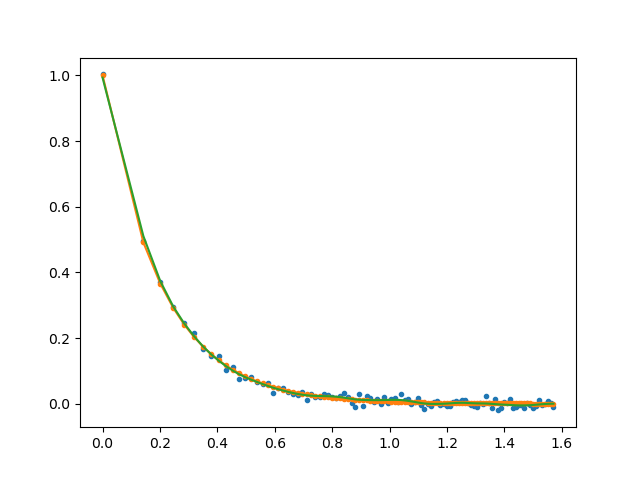

In [2]:
mu = np.linspace(1,0,100)
theta = np.arccos(mu)

y2 = func(theta) + np.random.normal(scale=0.01, size=n)

splfit_2 = make_smoothing_spline(theta, y2)

fig,ax = plt.subplots()
ax.plot(theta, y2, '.')
ax.plot(theta, func(theta),'.-')
ax.plot(theta, splfit_2(theta))
plt.show()


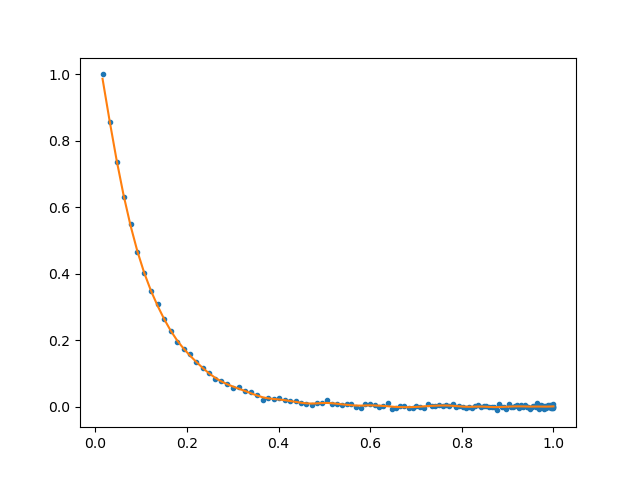

In [3]:
# first define functions for reference use
B_star = 1e8
R_star = 1e4
psi_star = B_star*R_star**2/2
bratio = 10
cs = 1e6
G = 6.67e-11
M_sol = 1.989e30
M_star = 1.4*M_sol
x0 = (cs*R_star)**2/G/M_star
ma = 5e-7*M_sol
psi_0 = np.sqrt(cs**2*ma/x0**3)
n_contours = 127
dmu = 1/n_contours
mu_levels = np.empty(n_contours)
    
for i in range(n_contours):
    contour_mesh_value = (n_contours - i)/(n_contours+1.)/dmu
    mu_levels[i] = contour_mesh_value*dmu
    
psi_levels = (psi_star/psi_0)*(1-mu_levels*mu_levels)
# psi_levels = np.append(np.append(0,psi_levels),psi_star/psi_0)
m_psi_ref = 0.5*(1 - np.exp(-psi_levels*psi_0/psi_star*bratio)) / (1 - np.exp(-bratio))
dmdpsi_ref = 0.5*bratio*psi_0/psi_star*np.exp(-psi_levels*psi_0/psi_star*bratio) / (1 - np.exp(-bratio))


noisy_data = dmdpsi_ref + np.random.normal(scale=10, size=n_contours)

spline_dmdpsi = make_smoothing_spline(psi_levels/psi_levels[-1], noisy_data/noisy_data[0])
fig,ax = plt.subplots()
ax.plot(psi_levels/psi_levels[-1],noisy_data/noisy_data[0],'.')
ax.plot(psi_levels/psi_levels[-1], spline_dmdpsi(psi_levels/psi_levels[-1]))
plt.show()